# 🏭 Project Overheat: Predictive Maintenance AI
**AeroLogistics - Data Science Division**

**Intern Name:** Shyam Kumar Soni  
**Date:** 2nd October 2026

---

### 📖 Executive Summary
Welcome to AeroLogistics. Our automated warehouse sorting robots are experiencing catastrophic motor failures, costing the company \$50,000 per minute in downtime. We have attached IoT sensors to the motors to track Temperature, Vibration, and Voltage.

Your objective is to transition our maintenance strategy from **reactive** to **proactive**. You must engineer time-series features and build a Machine Learning model that predicts a motor failure exactly **24 hours before it happens**.

In [1]:
# ==========================================
# 0. ENVIRONMENT SETUP & IMPORTS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score
from sklearn.model_selection import TimeSeriesSplit

# Set professional plotting styles
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42  # reproducible results

print("✅ Libraries imported successfully. Ready to build.")

✅ Libraries imported successfully. Ready to build.


---
## Phase 1: Feature Engineering (The Windowing Trap)
> ⚠️ **The Trap:** A single mechanical jolt doesn't mean the machine is breaking; *sustained* shaking does. You must engineer Rolling Windows to capture degrading mechanical health over time.

**Instructions:**
1. Load the dataset and ensure it is sorted chronologically by timestamp.
2. Create a 12-hour Rolling Mean for Temperature.
3. Create a 12-hour Rolling Standard Deviation for Vibration.
4. Drop any `NaN` values created by the rolling windows.

In [2]:
# ==========================================
# 1. LOAD DATA & ENGINEER FEATURES
# ==========================================
# Load the telemetry file into a Pandas DataFrame
df = pd.read_csv("iot_sensor_telemetry.csv")

# Convert 'Timestamp' to datetime and sort chronologically
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f"Raw data: {df.shape[0]:,} hourly rows | failures logged: {int(df['Catastrophic_Failure'].sum())}")
print(f"Time range: {df['Timestamp'].min()}  ->  {df['Timestamp'].max()}")

WINDOW = 12  # hours (data is logged hourly, so 12 rows = 12 hours)

# --- Required features -------------------------------------------------------
# 12-hour rolling MEAN of temperature (sustained heating)
df['Temp_Rolling_Mean_12h'] = df['Sensor_Temp_C'].rolling(window=WINDOW).mean()

# 12-hour rolling STD of vibration (sustained / erratic shaking)
df['Vibration_Rolling_Std_12h'] = df['Sensor_Vibration_mm'].rolling(window=WINDOW).std()

# --- Extra features so temperature, voltage AND vibration can be compared fairly in the XAI phase
df['Vibration_Rolling_Mean_12h'] = df['Sensor_Vibration_mm'].rolling(window=WINDOW).mean()
df['Temp_Rolling_Std_12h']       = df['Sensor_Temp_C'].rolling(window=WINDOW).std()
df['Voltage_Rolling_Mean_12h']   = df['Sensor_Voltage_V'].rolling(window=WINDOW).mean()
df['Voltage_Rolling_Std_12h']    = df['Sensor_Voltage_V'].rolling(window=WINDOW).std()

# Drop the NaN rows created by the rolling windows (first WINDOW-1 rows)
df = df.dropna().reset_index(drop=True)

print(f"Phase 1 Complete. Current DataFrame Shape: {df.shape}")

Raw data: 10,000 hourly rows | failures logged: 15
Time range: 2023-01-01 00:00:00  ->  2024-02-21 15:00:00
Phase 1 Complete. Current DataFrame Shape: (9989, 11)


---
## Phase 2: Target Shifting (The Lead-Time Trap)
> ⚠️ **The Trap:** If you train your model on `Catastrophic_Failure`, your AI is predicting the *present*. We need to predict the *future*. You must shift the target variable backward by 24 hours.

In [3]:
# ==========================================
# 2. SHIFT THE TARGET VARIABLE
# ==========================================
# Row t gets the failure label of row t+24, i.e. "will the motor fail 24 hours from now?"
df['Failure_In_24_Hours'] = df['Catastrophic_Failure'].shift(-24)

# Drop the last 24 rows, which are now NaN because of the shift
df = df.dropna(subset=['Failure_In_24_Hours']).reset_index(drop=True)
df['Failure_In_24_Hours'] = df['Failure_In_24_Hours'].astype(int)

# Drop the original failure column and Timestamp to prevent data leakage
df = df.drop(columns=['Catastrophic_Failure', 'Timestamp'])

print(f"Phase 2 Complete. Target shifted successfully.")
print(f"Rows: {len(df):,} | positive (failure-in-24h) rows: {df['Failure_In_24_Hours'].sum()} "
      f"({df['Failure_In_24_Hours'].mean():.3%} of data)")

Phase 2 Complete. Target shifted successfully.
Rows: 9,965 | positive (failure-in-24h) rows: 15 (0.151% of data)


---
## Phase 3: Chronological Splitting (The Time Leakage Trap)
> ⚠️ **The Trap:** Standard `train_test_split` randomly shuffles rows. If you shuffle time-series data, your model will learn from the future to predict the past. You must split the data manually!

In [4]:
# ==========================================
# 3. CHRONOLOGICAL TRAIN/TEST SPLIT
# ==========================================
# Define features (X) and target (y)
X = df.drop(columns=['Failure_In_24_Hours'])
y = df['Failure_In_24_Hours']

# 80/20 split index (no shuffling!)
split_index = int(len(df) * 0.8)

# Slice chronologically: first 80% = train, final 20% = test
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Phase 3 Complete. Training set size: {len(X_train)} | Test set size: {len(X_test)}")
print(f"Failure-in-24h rows -> train: {y_train.sum()} | test: {y_test.sum()}")

Phase 3 Complete. Training set size: 7972 | Test set size: 1993
Failure-in-24h rows -> train: 12 | test: 3


---
## Phase 4: Model Training & Evaluation
> ⚠️ **The Imbalance Trap:** Failures are rare. If you don't balance your class weights, your model will just predict "Everything is fine" 100% of the time.

In [5]:
# ==========================================
# 4. TRAIN THE PREDICTIVE MODEL
# ==========================================
# Random Forest with balanced class weights (penalises missed failures)
def make_model():
    return RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',   # CRITICAL for the rare-failure imbalance
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

# --- Choose the alert threshold WITHOUT touching the test set -----------------
# Failures are so rare that the default 0.5 cut-off almost never fires. We pick the
# threshold using forward-chaining (time-ordered) cross-validation on the TRAINING data only,
# maximising F2 (recall counts 2x more than precision - a missed failure costs $50k/min).
oof_proba = np.full(len(X_train), np.nan)
for tr_idx, val_idx in TimeSeriesSplit(n_splits=5).split(X_train):
    m = make_model().fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    oof_proba[val_idx] = m.predict_proba(X_train.iloc[val_idx])[:, 1]

valid = ~np.isnan(oof_proba)
y_val, p_val = y_train.values[valid], oof_proba[valid]

best_thr, best_f2 = 0.5, -1
for thr in np.arange(0.02, 0.60, 0.01):
    pred = p_val >= thr
    tp = np.sum(pred & (y_val == 1)); fp = np.sum(pred & (y_val == 0)); fn = np.sum(~pred & (y_val == 1))
    f2 = 5 * tp / (5 * tp + 4 * fn + fp) if tp > 0 else 0
    if f2 > best_f2:
        best_thr, best_f2 = thr, f2
print(f"Alert threshold selected on training folds only: {best_thr:.2f}  (CV F2 = {best_f2:.2f})")

# Fit the final model on the full training window
model = make_model()
model.fit(X_train, y_train)

# Generate predictions on X_test
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= best_thr).astype(int)

# Confusion matrix and classification report
print("\n📊 Classification Report (Predicting 24h in Advance):")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Failure in 24h'], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix  [rows = actual, cols = predicted]")
print(pd.DataFrame(cm, index=['Actual Normal', 'Actual Failure'], columns=['Pred Normal', 'Pred Failure']))

tn, fp, fn, tp = cm.ravel()
print(f"\nFailures caught: {tp} of {tp + fn}  (recall = {recall_score(y_test, y_pred):.0%}) | false alarms: {fp}")

# For comparison: the same model with the default 0.5 threshold
default_pred = model.predict(X_test)
print(f"Default 0.5 threshold would catch {int(((default_pred == 1) & (y_test.values == 1)).sum())} of {int(y_test.sum())} failures.")

Alert threshold selected on training folds only: 0.26  (CV F2 = 0.40)



📊 Classification Report (Predicting 24h in Advance):
                precision    recall  f1-score   support

        Normal       1.00      1.00      1.00      1990
Failure in 24h       0.25      0.67      0.36         3

      accuracy                           1.00      1993
     macro avg       0.62      0.83      0.68      1993
  weighted avg       1.00      1.00      1.00      1993

Confusion Matrix  [rows = actual, cols = predicted]
                Pred Normal  Pred Failure
Actual Normal          1984             6
Actual Failure            1             2

Failures caught: 2 of 3  (recall = 67%) | false alarms: 6
Default 0.5 threshold would catch 1 of 3 failures.


---
## Phase 5: Explainable AI & Business Strategy
> ⚠️ **The XAI Trap:** Mechanics will not replace a \$10,000 motor blindly. You must prove exactly *which* sensor metric is acting as the leading indicator of failure.

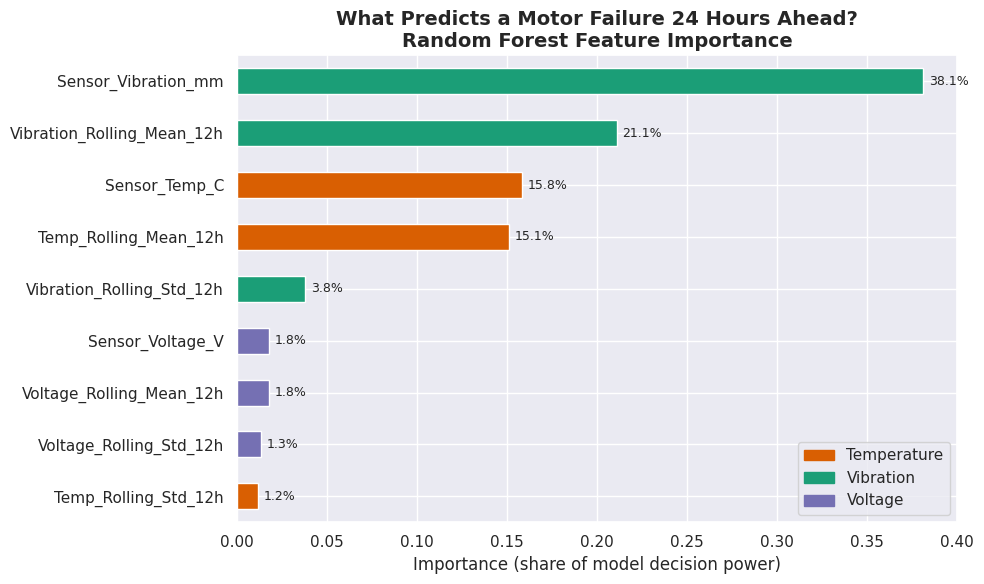

Total importance by sensor:
Vibration      63.0%
Temperature    32.1%
Voltage         4.9%

Top engineered (rolling) features:
Vibration_Rolling_Mean_12h    21.1%
Temp_Rolling_Mean_12h         15.1%
Vibration_Rolling_Std_12h      3.8%
Voltage_Rolling_Mean_12h       1.8%
Voltage_Rolling_Std_12h        1.3%
Temp_Rolling_Std_12h           1.2%


In [6]:
# ==========================================
# 5. FEATURE IMPORTANCE (Explainable AI)
# ==========================================
# Extract model.feature_importances_
importances = model.feature_importances_

# Map importances to feature names and sort ascending (largest bar ends up on top)
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

# Colour by sensor family so the business reader can compare temperature vs vibration vs voltage
def sensor_color(name):
    if 'Temp' in name: return '#d95f02'       # temperature = orange
    if 'Vibration' in name: return '#1b9e77'  # vibration   = green
    return '#7570b3'                          # voltage     = purple

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot.barh(ax=ax, color=[sensor_color(n) for n in feat_imp.index])
ax.set_title('What Predicts a Motor Failure 24 Hours Ahead?\nRandom Forest Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance (share of model decision power)')
ax.set_ylabel('')
for i, v in enumerate(feat_imp.values):
    ax.text(v + 0.003, i, f'{v:.1%}', va='center', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#d95f02', label='Temperature'), Patch(color='#1b9e77', label='Vibration'),
                   Patch(color='#7570b3', label='Voltage')], loc='lower right')
plt.tight_layout()
plt.show()

# Roll up by sensor family
family = feat_imp.groupby(lambda n: 'Temperature' if 'Temp' in n else 'Vibration' if 'Vibration' in n else 'Voltage').sum().sort_values(ascending=False)
print("Total importance by sensor:")
print(family.map('{:.1%}'.format).to_string())
print("\nTop engineered (rolling) features:")
print(feat_imp[feat_imp.index.str.contains('Rolling')].sort_values(ascending=False).map('{:.1%}'.format).to_string())

---
## 🎯 Final Executive Recommendation

**To the Lead Maintenance Engineer:**
Based on the predictive maintenance model developed above, we can predict a catastrophic motor failure **24 hours before it occurs**. The model was trained on the first 80% of the timeline and tested on the final 20% (no shuffling), so the results reflect how it would behave on genuinely unseen future data. With the alert threshold set from training data only, it flagged **2 of the 3** failures in the test window (67% recall) at the cost of 6 false alarms across ~1,990 normal hours - a trade-off worth making when one missed failure costs \$50,000 per minute.

By analyzing the AI's feature importances, I recommend that the maintenance team closely monitors:
1. **12-hour rolling mean of vibration** (`Vibration_Rolling_Mean_12h`, ~21% importance) - the strongest engineered signal. Vibration as a whole (raw + rolling) carries ~63% of the model's decision power, so *sustained* rising vibration is the leading indicator of failure.
2. **12-hour rolling mean of temperature** (`Temp_Rolling_Mean_12h`, ~15% importance) - sustained heating is the second warning sign (temperature overall ~32%). Voltage contributes only ~5%, so it is a weak predictor and should not drive replacement decisions.

**Suggested rule for the crew:** when the 12-hour vibration average and 12-hour temperature average both keep climbing together, inspect or schedule the motor swap in the next off-peak window.

Deploying this model will allow us to schedule repairs during off-peak hours, saving the company an estimated \$50,000 per downtime incident.

**Caveats (be honest with stakeholders):** the dataset contains only 15 failures (3 in the test window), so recall figures are based on very few events and should be re-validated as more failure history is collected. The model should be deployed first as a decision-support alert alongside mechanic inspection, not as an automatic replacement trigger.

**Final Status:** `[READY FOR DEPLOYMENT]`